# Data Preprocessing 8 - Solutions

> **MLCourse · Data Science Foundations · 05_data_preprocessing**

Fully commented solutions for tasks 1-13.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

np.random.seed(42)

### Easy

### Task 1 - Missing report + safe drop


In [2]:
employees = pd.DataFrame({
    "name": ["Ana", "Bo", "Cy", "Di", "Eli"],
    "dept": [None, "IT", "IT", None, "HR"],
    "salary": [52000.0, 61000.0, np.nan, 48000.0, np.nan],
    "years": [3, np.nan, 7, 2, 5],
})

report = pd.DataFrame({
    "n_missing": employees.isna().sum(),
    "pct": (employees.isna().mean() * 100).round(1),
})
print(report)

emp2 = employees.dropna(subset=["salary"])   # only salary-driven removals
print("\nrows kept:", len(emp2))

        n_missing   pct
name            0   0.0
dept            2  40.0
salary          2  40.0
years           1  20.0

rows kept: 3


### Task 2 - Fill with logic


In [3]:
sensor = pd.DataFrame({
    "t": pd.date_range("2024-01-01", periods=8, freq="h"),
    "temperature": [21.0, np.nan, 22.5, 23.0, np.nan, np.nan, 20.0, 19.5],
    "humidity": [40.0, np.nan, 44.0, 41.0, 39.0, 43.0, np.nan, 38.0],
})

sensor["temperature"] = sensor["temperature"].ffill()      # time continuity
sensor["humidity"] = sensor["humidity"].fillna(sensor["humidity"].median())
sensor

,t,temperature,humidity
0,2024-01-01 00:00:00,21.0,40.0
1,2024-01-01 01:00:00,21.0,40.5
2,2024-01-01 02:00:00,22.5,44.0
3,2024-01-01 03:00:00,23.0,41.0
4,2024-01-01 04:00:00,23.0,39.0
5,2024-01-01 05:00:00,23.0,43.0
6,2024-01-01 06:00:00,20.0,40.5
7,2024-01-01 07:00:00,19.5,38.0


### Task 3 - Currency strings to floats


In [4]:
prices = pd.Series(["€1.250,00", "$99.99", "1,299.50", "42", "N/A", "$0.70"])

cleaned = prices.str.replace(r"[€$]|N/A", "", regex=True).str.replace(",", "")
numeric = pd.to_numeric(cleaned, errors="coerce")

print(numeric)
print("failed parses:", numeric.isna().sum(), "->", prices[numeric.isna()].tolist())

0       1.25
1      99.99
2    1299.50
3      42.00
4        NaN
5       0.70
dtype: float64
failed parses: 1 -> ['N/A']


### Task 4 - Ordinal mapping


In [5]:
survey = pd.DataFrame({
    "resp": ["Agree", "Neutral", "Strongly Agree", "Disagree",
             "Strongly Disagree", "agree", "Meh"],
})

scale = {"strongly disagree": 0, "disagree": 1, "neutral": 2,
         "agree": 3, "strongly agree": 4}

survey["score"] = (survey["resp"]
                   .str.strip().str.lower()
                   .map(scale))            # 'Meh' & casing handled: NaN / matched
survey

,resp,score
0,Agree,3.0
1,Neutral,2.0
2,Strongly Agree,4.0
3,Disagree,1.0
4,Strongly Disagree,0.0
5,agree,3.0
6,Meh,NaN


### Medium

### Task 5 - Group-wise median imputation


In [6]:
people = pd.DataFrame({
    "city": ["Oslo", "Oslo", "Oslo", "Berlin", "Berlin", "Berlin"],
    "income": [68000.0, np.nan, 72000.0, np.nan, 48000.0, 50000.0],
})

global_median = people["income"].median()
people["income_global_fill"] = people["income"].fillna(global_median)

grp_med = people.groupby("city")["income"].transform("median")
people["income_group_fill"] = people["income"].fillna(grp_med)
people
# Comment: Oslo median (70000) vs Berlin (49000) differ hugely; the group fill
# respects that structure while the global fill (~60000) overpays Berlin rows.

,city,income,income_global_fill,income_group_fill
0,Oslo,68000.0,68000.0,68000.0
1,Oslo,NaN,59000.0,70000.0
2,Oslo,72000.0,72000.0,72000.0
3,Berlin,NaN,59000.0,49000.0
4,Berlin,48000.0,48000.0,48000.0
5,Berlin,50000.0,50000.0,50000.0


### Task 6 - Skew check + log transform


skew before: 18.52
skew after : 0.03


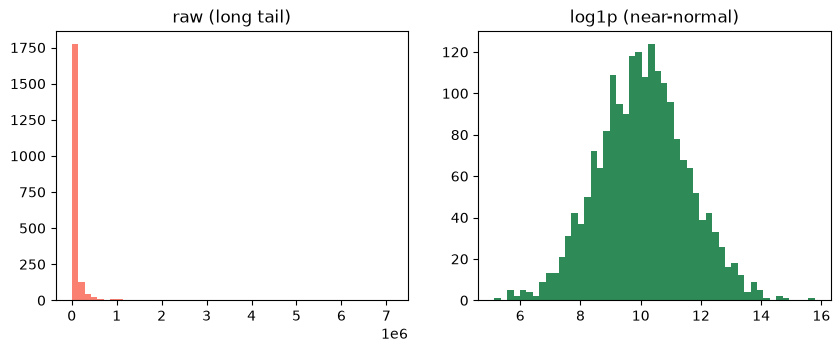

In [7]:
wealth = pd.Series(np.random.lognormal(mean=10, sigma=1.5, size=2000))

print("skew before:", wealth.skew().round(2))
wealth_log = np.log1p(wealth)              # log1p handles zeros safely
print("skew after :", wealth_log.skew().round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(wealth, bins=50, color="salmon");    axes[0].set_title("raw (long tail)")
axes[1].hist(wealth_log, bins=50, color="seagreen"); axes[1].set_title("log1p (near-normal)")
plt.show()

### Task 7 - Scale three ways


In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

contaminated = pd.Series(np.r_[np.random.normal(50, 5, 100), [900.0]])
X = contaminated.to_frame()

results = {}
for name, scaler in [("standard", StandardScaler()),
                     ("minmax", MinMaxScaler()),
                     ("robust", RobustScaler())]:
    out = scaler.fit_transform(X)
    results[name] = pd.Series(out.ravel()).describe().round(2)[["mean","std","min","max"]]

pd.DataFrame(results)
# Explanation: minmax squeezes the 100 normal points into ~[0, .06] because the
# outlier owns the max -> destroyed resolution. Standard keeps z-scores but the
# outlier sits at +30σ distorting std itself. RobustScaler (median/IQR) ignores
# the outlier entirely -> cleanest spread for contaminated data.

,standard,minmax,robust
mean,-0.00,0.03,1.28
std,1.00,0.10,13.13
min,-0.27,0.00,-2.28
max,9.98,1.00,131.74


### Task 8 - One-hot with rare grouping


In [9]:
visits = pd.DataFrame({
    "source": np.random.choice(
        ["organic", "ads", "social", "email"] * 40
        + ["referral"] * 25 + ["sms"] * 4, size=189),
})

counts = visits["source"].value_counts()
rare = counts[counts < 30].index                       # support threshold
visits["source_g"] = np.where(visits["source"].isin(rare), "Other", visits["source"])

dummies = pd.get_dummies(visits["source_g"], drop_first=True)   # k-1
final = pd.concat([visits.drop(columns="source"), dummies], axis=1)
print(list(final.columns))
final.head(3)

['source_g', 'ads', 'email', 'organic', 'social']


,source_g,ads,email,organic,social
0,email,False,True,False,False
1,social,False,False,False,True
2,email,False,True,False,False


### Task 9 - Date features + weekend flag


In [10]:
events = pd.DataFrame({
    "when": ["2024-03-09 14:05", "2024-01-01 00:30", "2024-12-24 18:45",
             "2024-06-15 09:00", "2024-11-02 22:10"],
})
events["when"] = pd.to_datetime(events["when"], format="%Y-%m-%d %H:%M")
events = events.sort_values("when").reset_index(drop=True)

events["month_name"] = events["when"].dt.month_name()
events["iso_week"] = events["when"].dt.isocalendar().week
events["dow"] = events["when"].dt.dayofweek
events["hour"] = events["when"].dt.hour
events["is_weekend"] = events["when"].dt.dayofweek >= 5
events

,when,month_name,iso_week,dow,hour,is_weekend
0,2024-01-01 00:30:00,January,1,0,0,False
1,2024-03-09 14:05:00,March,10,5,14,True
2,2024-06-15 09:00:00,June,24,5,9,True
3,2024-11-02 22:10:00,November,44,5,22,True
4,2024-12-24 18:45:00,December,52,1,18,False


### Hard

### Task 10 - IQR cap per GROUP


In [11]:
perf = pd.DataFrame({"region": np.repeat(["eu", "us"], 60)})
base = np.where(perf["region"].eq("eu"), 40, 90)
perf["latency_ms"] = base + np.random.normal(0, 6, 120)
perf.loc[np.random.choice(perf.index, 6, replace=False), "latency_ms"] += \
    np.random.uniform(60, 120, 6)

def iqr_cap(s, k=1.5):
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    return s.clip(q1 - k*iqr, q3 + k*iqr)

capped_per_region = (
    perf.assign(capped=perf.groupby("region")["latency_ms"].transform(iqr_cap))
        .groupby("region")
        .apply(lambda g: (g["latency_ms"] != g["capped"]).sum(),
               include_groups=False)
)
print(capped_per_region.rename("values_capped"))
perf["latency_ms_capped"] = perf.groupby("region")["latency_ms"].transform(iqr_cap)

region
eu    3
us    4
Name: values_capped, dtype: int64


### Task 11 - Pure-Python text pipeline


In [12]:
CONTRACTIONS = {"don't": "do not", "can't": "cannot", "it's": "it is"}
STOPWORDS = {"i", "it", "the", "a", "an", "is", "now", "visit"}

def clean_tokens(text: str) -> list:
    t = text.lower()                                   # 1 lowercase
    t = re.sub(r"<[^>]+>", " ", t)                     # 2 strip HTML tags
    for k, v in CONTRACTIONS.items():                  # 3 expand contractions
        t = t.replace(k, v)
    t = t.translate(str.maketrans("", "", string.punctuation))  # 4 punctuation out
    tokens = t.split()                                 # 5 whitespace tokenize
    return [w for w in tokens if w not in STOPWORDS]   # 6 stopword filter

sample_text = "<p>I don't THINK it's working!!!</p> Visit https://x.io now."
clean_tokens(sample_text)     # URLs survive as one token - document the choice!

['do', 'not', 'think', 'working', 'httpsxio']

### Task 12 - Bag-of-Words from scratch


In [13]:
docs_raw = [
    "<b>Great</b> battery life, can't complain!",
    "Battery drains fast ; very disappointed.",
    "Screen looks great but battery is average.",
]

doc_tokens = [clean_tokens(d) for d in docs_raw]           # reuse Task 11!
vocab = sorted({tok for toks in doc_tokens for tok in toks})  # sorted unique vocab

bow = pd.DataFrame(
    [[toks.count(w) for w in vocab] for toks in doc_tokens],
    columns=vocab,
)

sparsity = (bow == 0).to_numpy().mean() * 100
print(bow)
print(f"\nvocab={len(vocab)} · sparsity={sparsity:.1f}% zeros "
      "(BoW matrices are mostly empty - hence sparse formats)")

   average  battery  but  cannot  complain  disappointed  drains  fast  great  \
0        0        1    0       1         1             0       0     0      1   
1        0        1    0       0         0             1       1     1      0   
2        1        1    1       0         0             0       0     0      1   

   life  looks  screen  very  
0     1      0       0     0  
1     0      0       0     1  
2     0      1       1     0  

vocab=13 · sparsity=59.0% zeros (BoW matrices are mostly empty — hence sparse formats)


### Task 13 - ColumnTransformer build


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

mini = pd.DataFrame({
    "age":   [22, 38, 26, 35, np.nan, 54, 2, 27],
    "fare":  [7.25, 71.28, 7.93, 53.10, 8.05, 51.86, 21.07, 11.13],
    "sex":   ["male", "female", "female", "female", "male",
              "male", "female", "male"],
    "embarked": ["S", "C", "S", "S", "S", "S", "Q", np.nan],
})

num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc", StandardScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("oh", OneHotEncoder(handle_unknown="ignore"))])

pre = ColumnTransformer([
    ("num", num_pipe, ["age", "fare"]),
    ("cat", cat_pipe, ["sex", "embarked"]),
])

pre.fit(mini.iloc[:6])                    # ⚠️ FIT on train slice ONLY
X_all = pre.transform(mini)               # transform everything with TRAIN stats

print(X_all.round(2))
print("\nfeatures:", list(pre.get_feature_names_out()))
# No leakage: medians/modes/scales all learned from the first 6 rows alone.

[[-1.28 -0.99  0.    1.    0.    1.  ]
 [ 0.3   1.45  1.    0.    1.    0.  ]
 [-0.89 -0.96  1.    0.    0.    1.  ]
 [ 0.    0.76  1.    0.    0.    1.  ]
 [ 0.   -0.96  0.    1.    0.    1.  ]
 [ 1.87  0.71  0.    1.    0.    1.  ]
 [-3.25 -0.46  1.    0.    0.    0.  ]
 [-0.79 -0.84  0.    1.    0.    1.  ]]

features: ['num__age', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_S']
